# Analyze FSG and AIRS data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
fgs_path = './data/train/1010375142/FGS1_signal_0.parquet'
fgs_data = pd.read_parquet(fgs_path)
print("FGS shape:", fgs_data.shape)
print("FGS columns:", fgs_data.columns if hasattr(fgs_data, 'columns') else 'Raw array')

FGS shape: (135000, 1024)
FGS columns: Index(['column_0', 'column_1', 'column_2', 'column_3', 'column_4', 'column_5',
       'column_6', 'column_7', 'column_8', 'column_9',
       ...
       'column_1014', 'column_1015', 'column_1016', 'column_1017',
       'column_1018', 'column_1019', 'column_1020', 'column_1021',
       'column_1022', 'column_1023'],
      dtype='object', length=1024)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train_gt = pd.read_csv('./data/train.csv')
star_info = pd.read_csv('./data/train_star_info.csv')

print('--- GROUND TRUTH ANALYSIS ---')
print(f"Shape: {train_gt.shape}")
print(f"Columns: {train_gt.columns[:10].tolist()}...") 
print(f"First few planet IDs: {train_gt['planet_id'].head()}")

wl_cols = [col for col in train_gt.columns if col.startswith('wl_')]
sigma_cols = [col for col in train_gt.columns if col.startswith('sigma_')]
print(f"Wavelength columns: {len(wl_cols)}")
print(f"Sigma columns: {len(sigma_cols)}")

--- GROUND TRUTH ANALYSIS ---
Shape: (1100, 284)
Columns: ['planet_id', 'wl_1', 'wl_2', 'wl_3', 'wl_4', 'wl_5', 'wl_6', 'wl_7', 'wl_8', 'wl_9']...
First few planet IDs: 0       34983
1     1873185
2     3849793
3     8456603
4    23615382
Name: planet_id, dtype: int64
Wavelength columns: 283
Sigma columns: 0


### AIRS

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint

def analyze_airs_spatial_signal(airs_data_dict, planet_ids=None, n_check=5, verbose=True):
    """
    Analyzes signal concentration in AIRS spatial dimension
    airs_data_dict: Dict[str->np.ndarray] with shape [T, 32, 356] per planet
    """
    if planet_ids is None:
        planet_ids = list(airs_data_dict.keys())[:n_check]
    
    results = {}
    
    for pid in planet_ids:
        if pid not in airs_data_dict:
            print(f"Planet {pid} wasn't found in airs_data!")
            continue
            
        airs_planet = airs_data_dict[pid]  # [T, 32, 356]
        
        if verbose:
            print(f"\nAnalysiere Planet {pid}...")
            print(f"  AIRS shape: {airs_planet.shape}")
        
        # Total signal over all spatial axes
        total_signal = np.abs(airs_planet).sum(axis=(1,2))  # [T]

        # Signal in central 24×356 (spatial crop, rows 4:28)
        center_signal = np.abs(airs_planet[:, 4:28, :]).sum(axis=(1,2))  # [T]
        
        # Background signal (top 4 + bottom 4 rows)
        background_signal = (np.abs(airs_planet[:, :4, :]).sum(axis=(1,2)) + 
                           np.abs(airs_planet[:, 28:, :]).sum(axis=(1,2)))  # [T]
        
        # Signal fractions
        center_fraction = center_signal / (total_signal + 1e-8)
        background_fraction = background_signal / (total_signal + 1e-8)
        
        mean_center_fraction = np.mean(center_fraction)
        mean_background_fraction = np.mean(background_fraction)

        # Spatial variance (Signal vs Background)
        center_region = airs_planet[:, 4:28, :].mean(axis=0)  # [24, 356]
        background_region = np.concatenate([
            airs_planet[:, :4, :].mean(axis=0),    # Top [4, 356]
            airs_planet[:, 28:, :].mean(axis=0)    # Bottom [4, 356]
        ], axis=0)  # [8, 356]
        
        center_std = np.std(center_region)
        background_std = np.std(background_region)
        signal_to_background_std = center_std / (background_std + 1e-8)

        # Signal-to-Noise ratio
        center_mean = np.mean(np.abs(center_region))
        background_mean = np.mean(np.abs(background_region))
        signal_to_background_mean = center_mean / (background_mean + 1e-8)
        
        results[pid] = {
            'center_signal_fraction': mean_center_fraction,
            'background_signal_fraction': mean_background_fraction,
            'signal_to_background_std_ratio': signal_to_background_std,
            'signal_to_background_mean_ratio': signal_to_background_mean,
            'recommendation': 'crop_and_downsample' if mean_center_fraction > 0.75 else 'keep_full_spatial'
        }
        
        if verbose:
            print(f"  Center signal fraction: {mean_center_fraction:.3f}")
            print(f"  Background signal fraction: {mean_background_fraction:.3f}")
            print(f"  Signal/Background (std): {signal_to_background_std:.3f}")
            print(f"  Signal/Background (mean): {signal_to_background_mean:.3f}")
            print(f"  Recommendation: {results[pid]['recommendation']}")
    
    return results

def plot_spatial_distribution(airs_data_dict, planet_id, frame_idx=100):
    """
    Plots spatial distribution over frame
    """
    if planet_id not in airs_data_dict:
        print(f"Planet {planet_id} not found!")
        return
    
    airs_planet = airs_data_dict[planet_id]
    
    if frame_idx >= len(airs_planet):
        frame_idx = len(airs_planet) // 2
        print(f"Frame index too high, using {frame_idx}")

    frame = airs_planet[frame_idx]  # [32, 356]

    # Spatial average over spectral dimension
    spatial_profile = np.mean(np.abs(frame), axis=1)  # [32]
    
    plt.figure(figsize=(12, 5))
    
    # Plot 1: Spatial Profile
    plt.subplot(1, 2, 1)
    plt.plot(spatial_profile, 'b-', linewidth=2)
    plt.axvspan(4, 28, alpha=0.3, color='green', label='Signal region (24 pixels)')
    plt.axvspan(0, 4, alpha=0.3, color='red', label='Background (top)')
    plt.axvspan(28, 32, alpha=0.3, color='red', label='Background (bottom)')
    plt.xlabel('Spatial Pixel Index')
    plt.ylabel('Mean Intensity')
    plt.title(f'Planet {planet_id}: Spatial Profile (Frame {frame_idx})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: 2D Frame visualization
    plt.subplot(1, 2, 2)
    # Show only first 100 spectral channels for clarity
    plt.imshow(frame[:, :100], aspect='auto', cmap='viridis')
    plt.axhline(y=4, color='red', linestyle='--', alpha=0.7)
    plt.axhline(y=28, color='red', linestyle='--', alpha=0.7)
    plt.xlabel('Spectral Channel')
    plt.ylabel('Spatial Pixel')
    plt.title(f'2D Frame View (first 100 channels)')
    plt.colorbar(label='Intensity')
    
    plt.tight_layout()
    plt.show()
    
    # Stats
    center_sum = np.sum(spatial_profile[4:28])
    total_sum = np.sum(spatial_profile)
    fraction = center_sum / total_sum
    
    print(f"\nSpatial Stats für Planet {planet_id}, Frame {frame_idx}:")
    print(f"  Center region (24 pixels): {center_sum:.2f}")
    print(f"  Total signal: {total_sum:.2f}")
    print(f"  Center fraction: {fraction:.3f}")

# MAIN TESTING CODE
def test_airs_spatial_analysis():
    """
    Main function to test the spatial analysis
    """
    print("🔥 AIRS Spatial Signal Analysis Test")
    print("="*50)
    # Load an AIRS chunk (adjust path to your setup)
    try:
        chunk_path = '/kaggle/input/10x-downsampled-dataset/airs_chunk_1.npy'
        print(f"Loading AIRS chunk: {chunk_path}")
        airs_chunk_data = np.load(chunk_path, allow_pickle=True).item()
        print(f"✅ Chunk loaded: {len(airs_chunk_data)} planets")
    except Exception as e:
        print(f"❌ Error loading chunk: {e}")
        print("Trying alternative paths...")

        # Alternative paths
        alternative_paths = [
            '/kaggle/input/10x-downsampled/airs_chunk_1.npy',
            './data/downsampled_dataset/airs_chunk_1.npy',
        ]
        
        airs_chunk_data = None
        for alt_path in alternative_paths:
            try:
                airs_chunk_data = np.load(alt_path, allow_pickle=True).item()
                print(f"✅ Alternative path successful: {alt_path}")
                break
            except:
                continue
        
        if airs_chunk_data is None:
            print("❌ No AIRS data found. Update path and retry!")
            return

    # Test on a few planets
    available_planets = list(airs_chunk_data.keys())
    test_planets = available_planets[:3] if len(available_planets) >= 3 else available_planets

    print(f"\nTesting {len(test_planets)} planets: {test_planets}")

    # Spatial analysis
    results = analyze_airs_spatial_signal(
        airs_chunk_data, 
        planet_ids=test_planets, 
        verbose=True
    )
    
    print("\n" + "="*50)
    print("SUMMARY:")
    print("="*50)
    
    # Aggregate results
    center_fractions = [r['center_signal_fraction'] for r in results.values()]
    avg_center_fraction = np.mean(center_fractions)
    
    signal_ratios = [r['signal_to_background_mean_ratio'] for r in results.values()]
    avg_signal_ratio = np.mean(signal_ratios)

    print(f"Average Center Signal Fraction: {avg_center_fraction:.3f}")
    print(f"Average Signal/Background Ratio: {avg_signal_ratio:.3f}")

    # Recommendation
    if avg_center_fraction > 0.75:
        print("\nRECOMMENDATION: Spatial Compression is advisable!")
        print(f"{avg_center_fraction:.1%} of the signal is in the central 24 pixels")
        print("Background subtraction + 24→16 downsampling recommended")
        compression_factor = (32*356) / (16*356)
        print(f"Expected compression: {compression_factor:.1f}× smaller")
    elif avg_center_fraction > 0.6:
        print("\nRECOMMENDATION: Spatial Compression possible but risky")
        print(f"Only {avg_center_fraction:.1%} of the signal in Center")
        print("Test with a small dataset recommended")
    else:
        print("\n❌ RECOMMENDATION: Spatial Compression not advisable")
        print(f"   Only {avg_center_fraction:.1%} of the signal in Center")
        print("   Too much signal would be lost")

    # Optional: Plot for first planet
    if len(test_planets) > 0:
        print(f"\nCreating spatial plot for planet {test_planets[0]}...")
        try:
            plot_spatial_distribution(airs_chunk_data, test_planets[0])
        except Exception as e:
            print(f"Plotting failed: {e}")
    
    return results

# EXECUTE
if __name__ == "__main__":
    results = test_airs_spatial_analysis()


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def load_original_airs_data(planet_ids, root_dir='./data/train', max_frames=1000):
    """
    Loads original AIRS files
    """
    airs_data = {}
    
    AIRS_ADC_GAIN = 0.4369
    AIRS_ADC_OFFSET = -1000.0
    
    for pid in planet_ids:
        airs_path = os.path.join(root_dir, str(pid), 'AIRS-CH0_signal_0.parquet')
        
        if not os.path.exists(airs_path):
            continue
            
        try:
            df = pd.read_parquet(airs_path)
            
            if df.shape[1] == 11392:  # 32 * 356 ✅
                raw_data = df.values.reshape(-1, 32, 356)
            else:
                continue
            
            # 1. ADC calibration
            calibrated = raw_data.astype(np.float32) * AIRS_ADC_GAIN + AIRS_ADC_OFFSET
            print(f"  After ADC: {calibrated.shape}, range: {calibrated.min():.1f} to {calibrated.max():.1f}")
            
            # 2. CDS
            if calibrated.shape[0] % 2:
                calibrated = calibrated[:-1]  # Even number frames
            
            cds = calibrated[1::2] - calibrated[::2]  # Odd - Even frames
            print(f"  After CDS: {cds.shape}, range: {cds.min():.1f} to {cds.max():.1f}")
            
            # 3. Limit frames
            if len(cds) > max_frames:
                cds = cds[:max_frames]
            
            airs_data[str(pid)] = cds
            print(f"  ✅ Final: {cds.shape}")
            
        except Exception as e:
            print(f"  ❌ Error: {e}")
    
    return airs_data

def analyze_original_airs_spatial_signal(airs_data_dict, planet_ids=None, n_check=3, verbose=True):
    """
    Spatial analysis
    """
    if planet_ids is None:
        planet_ids = list(airs_data_dict.keys())[:n_check]
    
    results = {}
    
    print("ORIGINAL AIRS Spatial Signal Analysis")
    print("="*60)
    
    for pid in planet_ids:
        if pid not in airs_data_dict:
            print(f"Planet {pid} wasn't found in airs_data!")
            continue
            
        airs_planet = airs_data_dict[pid]  # [T, 32, 356]
        
        if verbose:
            print(f"\nAnalyzing planet {pid}...")
            print(f"AIRS shape: {airs_planet.shape}")
        
        total_signal = np.abs(airs_planet).sum(axis=(1,2))
        center_signal = np.abs(airs_planet[:, 4:28, :]).sum(axis=(1,2))
        inner_center_signal = np.abs(airs_planet[:, 8:24, :]).sum(axis=(1,2))
        background_signal = (np.abs(airs_planet[:, :4, :]).sum(axis=(1,2)) + 
                           np.abs(airs_planet[:, 28:, :]).sum(axis=(1,2)))
        edge_signal = (np.abs(airs_planet[:, 4:8, :]).sum(axis=(1,2)) + 
                      np.abs(airs_planet[:, 24:28, :]).sum(axis=(1,2)))
        
        center_fraction = np.mean(center_signal / (total_signal + 1e-8))
        inner_center_fraction = np.mean(inner_center_signal / (total_signal + 1e-8))
        background_fraction = np.mean(background_signal / (total_signal + 1e-8))
        edge_fraction = np.mean(edge_signal / (total_signal + 1e-8))
        
        center_mean = np.mean(center_signal)
        background_mean = np.mean(background_signal)
        signal_to_background = center_mean / (background_mean + 1e-8)
        
        # Decision criteria
        if center_fraction > 0.8 and signal_to_background > 5.0:
            recommendation = "Strong: spatial compression highly recommended"
            compression_recommended = True
        elif center_fraction > 0.7 and signal_to_background > 3.0:
            recommendation = "Good: spatial compression recommended"
            compression_recommended = True
        elif center_fraction > 0.6:
            recommendation = "Maybe: spatial compression is risky but possible"
            compression_recommended = False
        else:
            recommendation = "No: spatial compression is not recommended"
            compression_recommended = False
        
        results[pid] = {
            'center_24_fraction': center_fraction,
            'inner_center_16_fraction': inner_center_fraction,
            'background_fraction': background_fraction,
            'edge_fraction': edge_fraction,
            'signal_to_background_ratio': signal_to_background,
            'compression_recommended': compression_recommended,
            'recommendation': recommendation
        }
        
        if verbose:
            print(f"Signal Fractions:")
            print(f"Center (24 rows): {center_fraction:.3f}")
            print(f"Inner center (16 rows): {inner_center_fraction:.3f}")
            print(f"Background (8 rows): {background_fraction:.3f}")
            print(f"Edge (8 rows): {edge_fraction:.3f}")
            print(f"Signal/Background ratio: {signal_to_background:.2f}")
            print(f"{recommendation}")
    
    return results

# MAIN TEST FUNCTION
def test_original_airs_spatial_analysis_fixed():
    print("Original AIRS dataset spatial analysis")
    print("="*60)
    
    root_dir = './data/train'
    if not os.path.exists(root_dir):
        print(f"Root directory not found: {root_dir}")
        return

    # Find available planets
    available_planets = []
    for entry in os.listdir(root_dir):
        planet_dir = os.path.join(root_dir, entry)
        if os.path.isdir(planet_dir):
            airs_file = os.path.join(planet_dir, 'AIRS-CH0_signal_0.parquet')
            if os.path.exists(airs_file):
                available_planets.append(entry)
    
    if not available_planets:
        print("No AIRS parquet files found.")
        return
    
    print(f"Found: {len(available_planets)} planets with AIRS data")
    
    test_planets = available_planets[:3]
    print(f"Testing: {test_planets}")

    airs_data = load_original_airs_data(test_planets, root_dir=root_dir, max_frames=500)
    
    if not airs_data:
        print("No AIRS data loaded.")
        return
    
    # Spatial analysis
    results = analyze_original_airs_spatial_signal(airs_data, verbose=True)
    
    # Summary
    if results:
        center_fractions = [r['center_24_fraction'] for r in results.values()]
        signal_ratios = [r['signal_to_background_ratio'] for r in results.values()]
        
        avg_center = np.mean(center_fractions)
        avg_signal_ratio = np.mean(signal_ratios)
        compression_count = sum([r['compression_recommended'] for r in results.values()])

        print(f"\n📋 SUMMARY:")
        print(f"Average Center Signal Fraction: {avg_center:.3f}")
        print(f"Average Signal/Background Ratio: {avg_signal_ratio:.2f}")
        print(f"Planets with Compression Recommendation: {compression_count}/{len(results)}")

        if avg_center > 0.75 and avg_signal_ratio > 4.0:
            print("\nConclusion: Spatial compression is highly recommended!")
        elif avg_center > 0.6:
            print("\nConclusion: Spatial compression is potentially beneficial.")
        else:
            print("\nConclusion: Spatial compression is too risky.")

    return results


results = test_original_airs_spatial_analysis_fixed()


🔥 ORIGINAL AIRS Dataset Spatial Analysis (FIXED)
✅ Gefunden: 1100 Planeten mit AIRS data
Teste: ['1010375142', '1024292144', '1029552010']
  Nach ADC: (11250, 32, 356), range: -915.2 to 14720.5
  Nach CDS: (5625, 32, 356), range: -153.4 to 15527.4
  ✅ Final: (500, 32, 356)
  Nach ADC: (11250, 32, 356), range: -917.9 to 14790.0
  Nach CDS: (5625, 32, 356), range: -140.7 to 15556.3
  ✅ Final: (500, 32, 356)
  Nach ADC: (11250, 32, 356), range: -995.6 to 14658.5
  Nach CDS: (5625, 32, 356), range: -291.0 to 15450.1
  ✅ Final: (500, 32, 356)
🔥 ORIGINAL AIRS Spatial Signal Analysis (CORRECTED)

Analysiere Planet 1010375142...
  AIRS shape: (500, 32, 356)
  📊 Signal Fractions:
    Center (24 rows): 0.990
    Inner center (16 rows): 0.973
    Background (8 rows): 0.010
    Edge (8 rows): 0.017
  📈 Signal/Background ratio: 96.85
  🎯 ✅ STRONG: Spatial compression empfohlen

Analysiere Planet 1024292144...
  AIRS shape: (500, 32, 356)
  📊 Signal Fractions:
    Center (24 rows): 0.992
    Inner c

  Nach ADC: (11250, 32, 356), range: -915.2 to 14720.5
  Nach CDS: (5625, 32, 356), range: -153.4 to 15527.4
  ✅ Final: (1000, 32, 356)
  Nach ADC: (11250, 32, 356), range: -917.9 to 14790.0
  Nach CDS: (5625, 32, 356), range: -140.7 to 15556.3
  ✅ Final: (1000, 32, 356)
  Nach ADC: (11250, 32, 356), range: -995.6 to 14658.5
  Nach CDS: (5625, 32, 356), range: -291.0 to 15450.1
  ✅ Final: (1000, 32, 356)



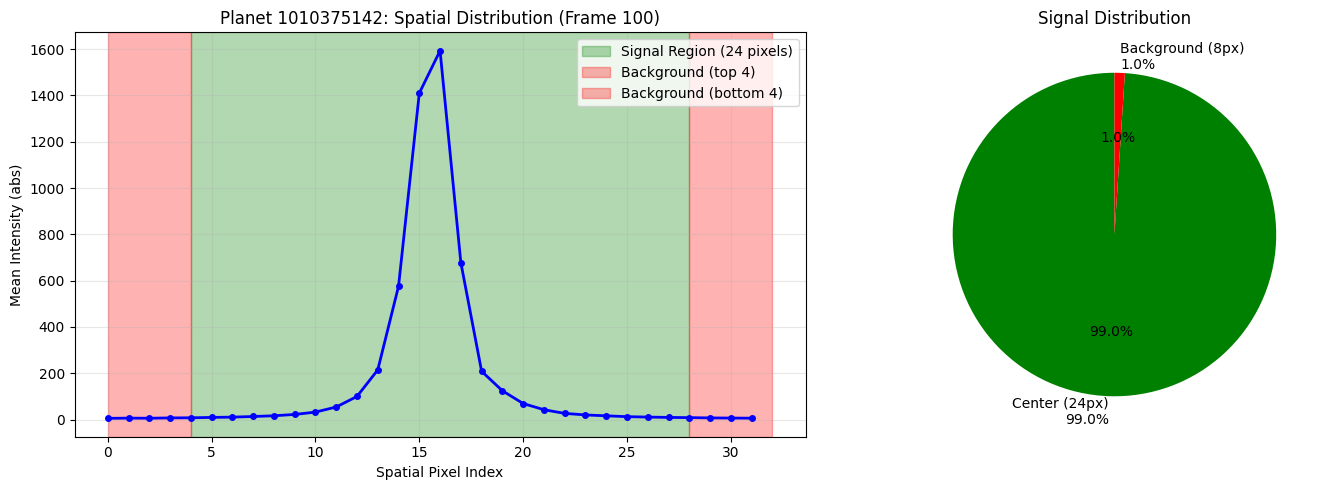


📊 Signal Stats für Planet 1010375142:
   Total signal: 5337.44
   Center signal (24px): 5282.52 (99.0%)
   Background signal (8px): 54.91 (1.0%)
   Signal concentration ratio: 96.20×



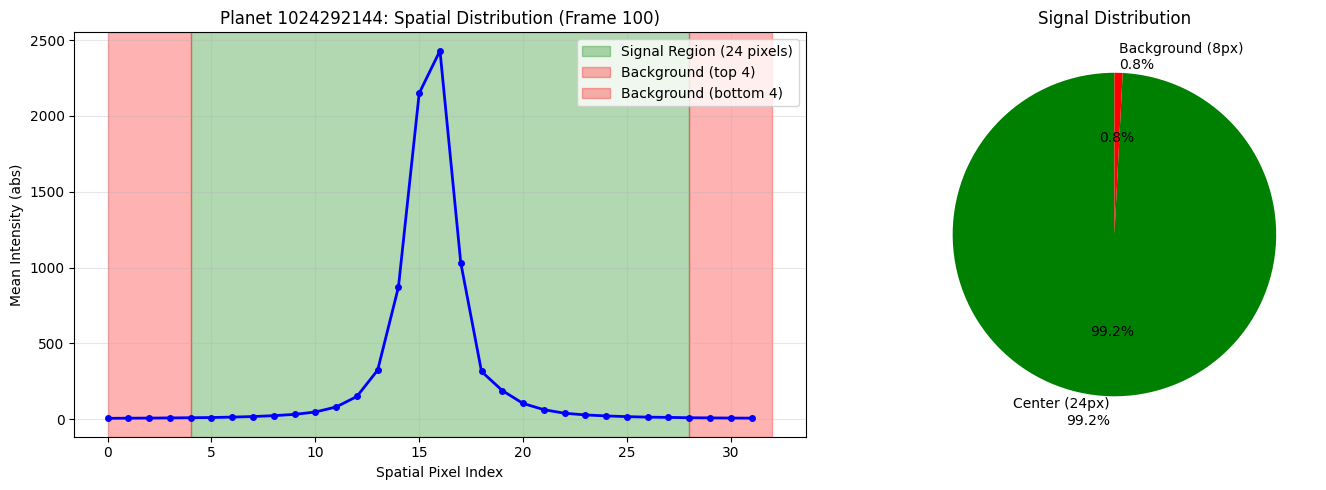


📊 Signal Stats für Planet 1024292144:
   Total signal: 8069.93
   Center signal (24px): 8004.29 (99.2%)
   Background signal (8px): 65.64 (0.8%)
   Signal concentration ratio: 121.95×



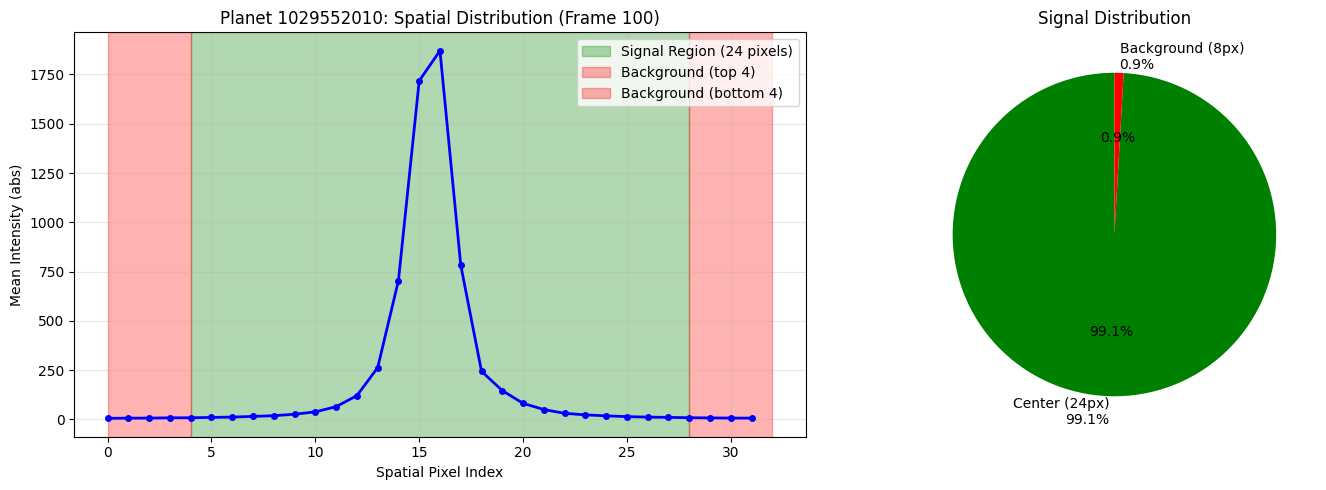


📊 Signal Stats für Planet 1029552010:
   Total signal: 6344.19
   Center signal (24px): 6286.42 (99.1%)
   Background signal (8px): 57.77 (0.9%)
   Signal concentration ratio: 108.82×

🎯 SUMMARY über 3 Planeten:
   Durchschnittliche Center-Fraktion: 99.1%
   Durchschnittliches Signal-Ratio: 109.0×
   ✅ Spatial compression EMPFOHLEN!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_airs_spatial_distribution(airs_data, planet_id, frame_idx=100):
    """
    Plots the spatial intensity over the 32 AIRS pixels.
    """
    if planet_id not in airs_data:
        print(f"Planet {planet_id} not found!")
        return
    
    data = airs_data[planet_id]  # [T, 32, 356]
    
    if frame_idx >= data.shape[0]:
        frame_idx = data.shape[0] // 2
        print(f"Frame index adjusted to {frame_idx}")

    frame = data[frame_idx]  # [32, 356]

    # Mean intensity over spectral dimension (356 channels)
    spatial_profile = np.mean(np.abs(frame), axis=1)  # [32]

    # Create plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot 1: Spatial Profile
    ax1.plot(range(32), spatial_profile, 'b-o', linewidth=2, markersize=4)
    ax1.axvspan(4, 28, alpha=0.3, color='green', label='Signal Region (24 pixels)')
    ax1.axvspan(0, 4, alpha=0.3, color='red', label='Background (top 4)')
    ax1.axvspan(28, 32, alpha=0.3, color='red', label='Background (bottom 4)')
    ax1.set_xlabel('Spatial Pixel Index')
    ax1.set_ylabel('Mean Intensity (abs)')
    ax1.set_title(f'Planet {planet_id}: Spatial Distribution (Frame {frame_idx})')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Plot 2: Signal contribution per region
    total_signal = np.sum(spatial_profile)
    center_signal = np.sum(spatial_profile[4:28])  # 24 pixels
    background_signal = np.sum(spatial_profile[:4]) + np.sum(spatial_profile[28:])  # 8 pixels
    
    fractions = [center_signal/total_signal, background_signal/total_signal]
    labels = [f'Center (24px)\n{fractions[0]:.1%}', f'Background (8px)\n{fractions[1]:.1%}']
    colors = ['green', 'red']
    
    ax2.pie(fractions, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    ax2.set_title('Signal Distribution')
    
    plt.tight_layout()
    plt.show()
    
    # Stats ausgeben
    print(f"\nSignal stats for planet {planet_id}:")
    print(f"Total signal: {total_signal:.2f}")
    print(f"Center signal (24px): {center_signal:.2f} ({fractions[0]:.1%})")
    print(f"Background signal (8px): {background_signal:.2f} ({fractions[1]:.1%})")
    print(f"Signal concentration ratio: {center_signal/background_signal:.2f}")

    return {
        'center_fraction': fractions[0],
        'background_fraction': fractions[1],
        'signal_ratio': center_signal/background_signal
    }


def analyze_multiple_planets(airs_data, n_planets=3):
    """Analyzes multiple planets and provides summary"""
    planets = list(airs_data.keys())[:n_planets]
    results = []
    
    for pid in planets:
        print(f"\n{'='*50}")
        result = plot_airs_spatial_distribution(airs_data, pid, frame_idx=100)
        results.append(result)
    
    # Summary
    avg_center = np.mean([r['center_fraction'] for r in results])
    avg_ratio = np.mean([r['signal_ratio'] for r in results])

    print(f"\nSUMMARY for {len(results)} planets:")
    print(f"Average Center Fraction: {avg_center:.1%}")
    print(f"Average Signal Ratio: {avg_ratio:.1f}")

    if avg_center > 0.75:
        print("Spatial compression recommended!")
    elif avg_center > 0.6:
        print("Spatial compression possible but risky")
    else:
        print("Spatial compression not recommended")

# Execute with your AIRS data:
# (First load your chunk or original data)

# For original parquet files:
airs_data = load_original_airs_data(['1010375142', '1024292144', '1029552010'])

# For chunk files:
# airs_data = np.load('/kaggle/input/10x-downsampled-dataset/airs_chunk_1.npy', allow_pickle=True).item()

# Then:
analyze_multiple_planets(airs_data, n_planets=3)



=== Planet 1010375142 ===


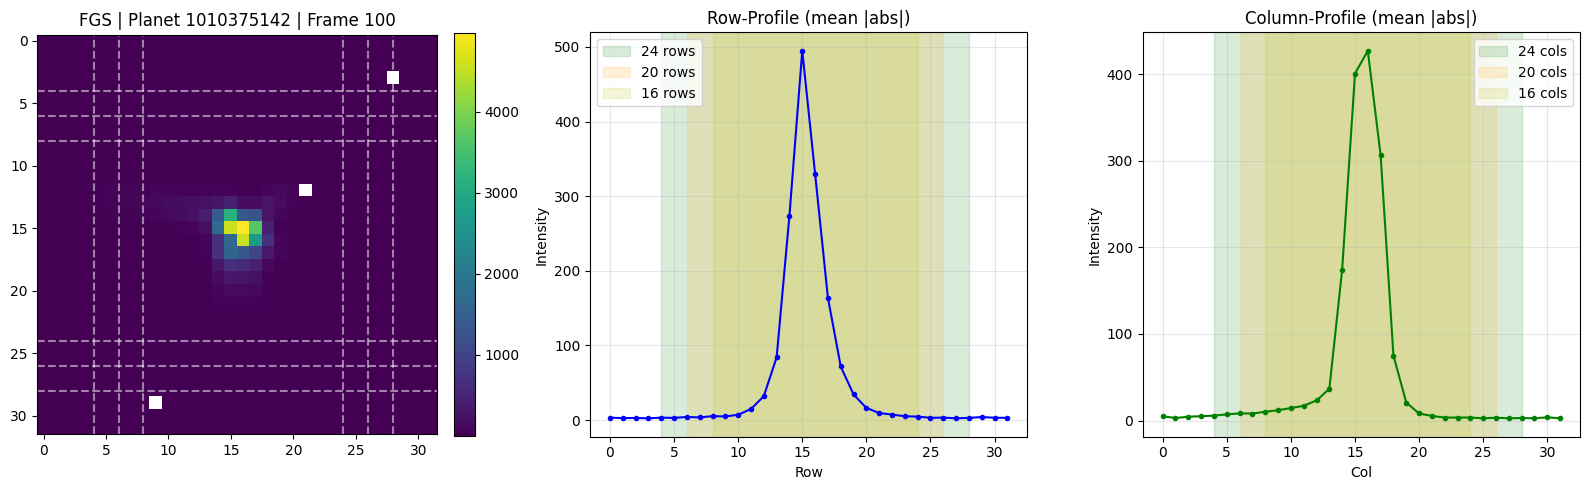

Spatial Fractions (calibrated):
 - center_24_fraction: 0.9699
 - inner_20_fraction: 0.9552
 - inner_16_fraction: 0.9386
 - background_fraction: 0.0301
Retention relativ zu 24x24 (Planet 1010375142):
- Direct 16x16 crop: 0.9677
- 20x20 → 16x16:    0.6094
- 24x24 → 16x16:    0.4386


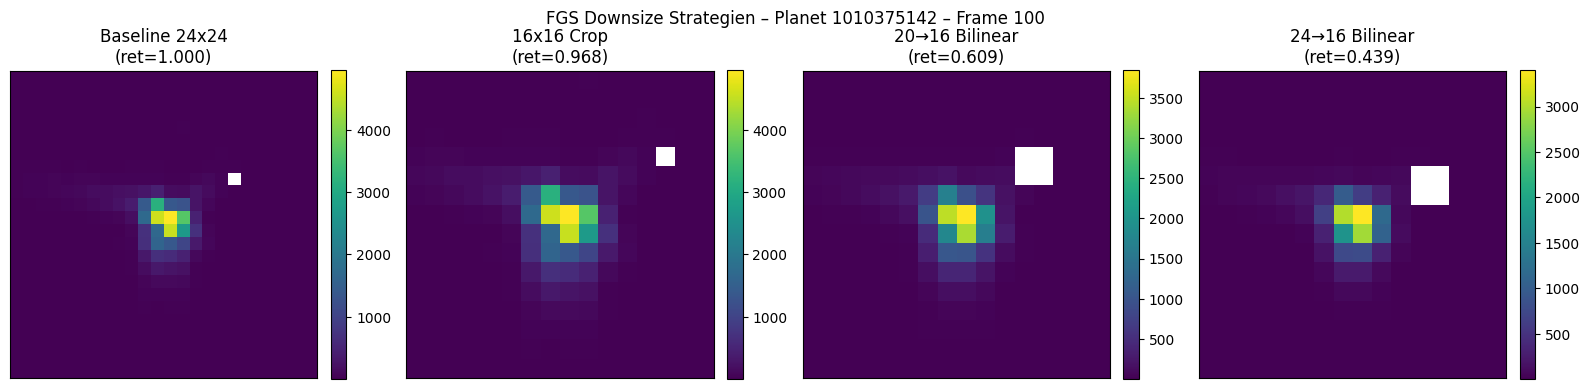


=== Planet 1024292144 ===


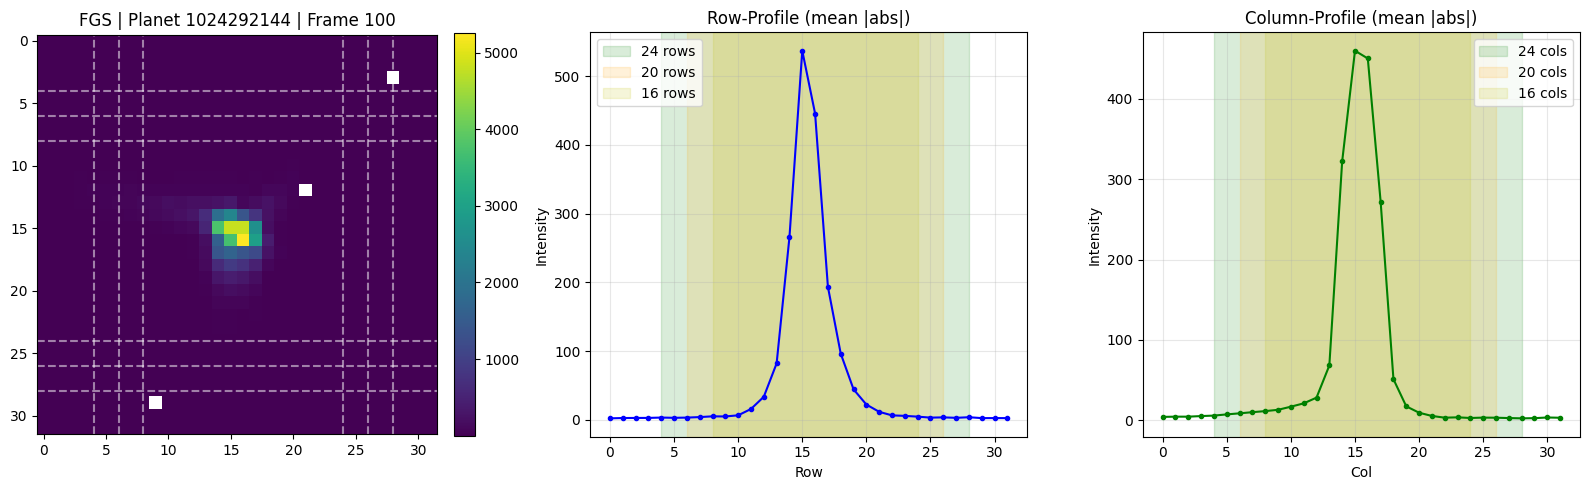

Spatial Fractions (calibrated):
 - center_24_fraction: 0.9731
 - inner_20_fraction: 0.9595
 - inner_16_fraction: 0.9436
 - background_fraction: 0.0269
Retention relativ zu 24x24 (Planet 1024292144):
- Direct 16x16 crop: 0.9697
- 20x20 → 16x16:    0.6108
- 24x24 → 16x16:    0.4395


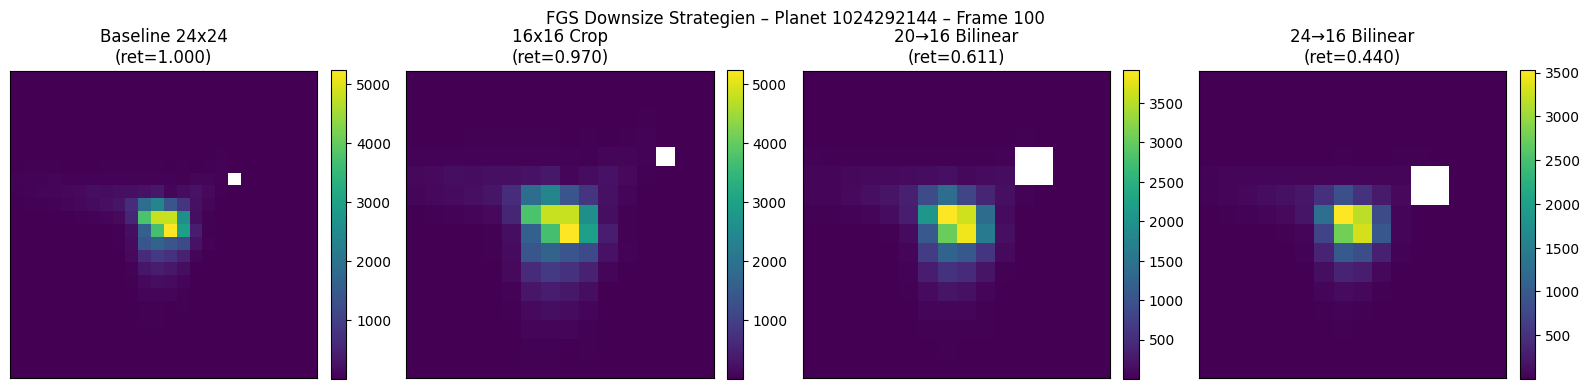


=== Planet 1029552010 ===


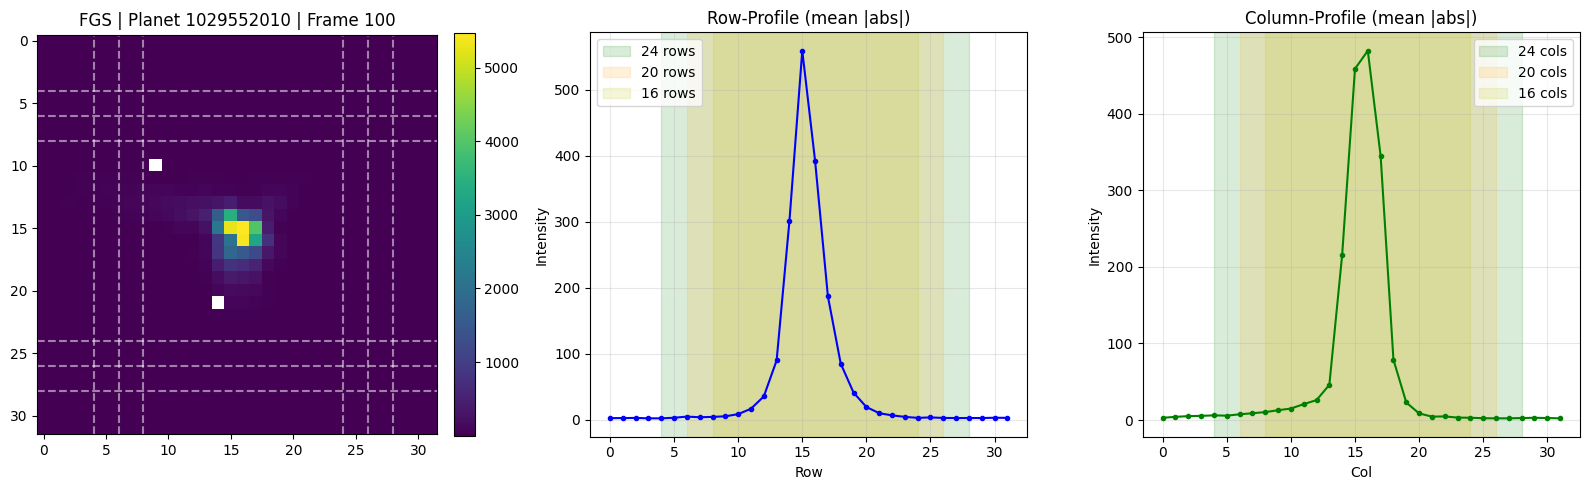

Spatial Fractions (calibrated):
 - center_24_fraction: 0.9736
 - inner_20_fraction: 0.9603
 - inner_16_fraction: 0.9446
 - background_fraction: 0.0264
Retention relativ zu 24x24 (Planet 1029552010):
- Direct 16x16 crop: 0.9703
- 20x20 → 16x16:    0.6067
- 24x24 → 16x16:    0.4378


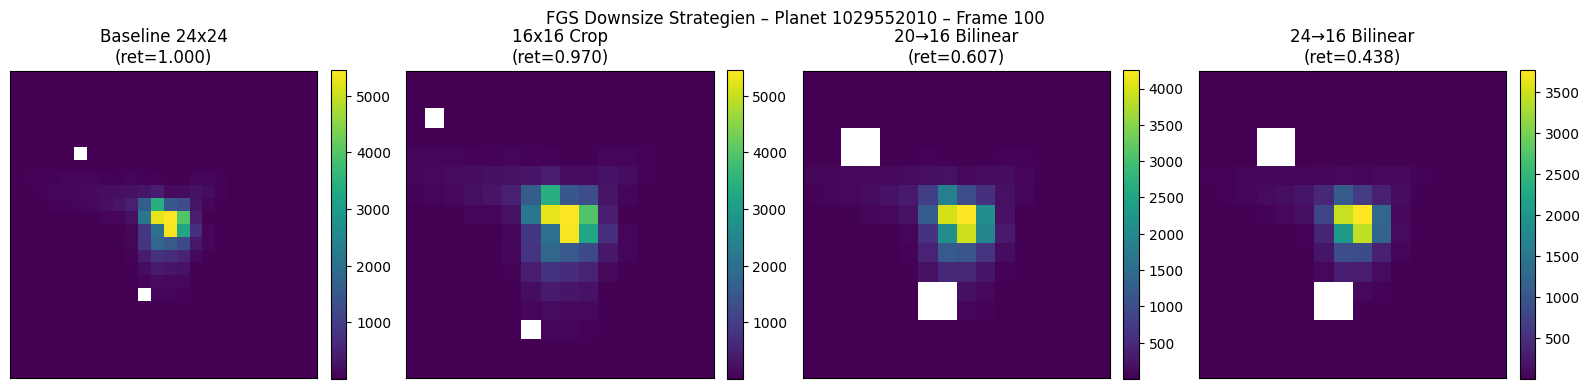


=== Durchschnittliche Retention (relativ zu 24x24) ===
Direct 16x16 crop: 0.9692
20x20 → 16x16:    0.6089
24x24 → 16x16:    0.4387
Empfehlung: Direct 16x16 Crop – schnell, simpel, kaum Verlust. **Fácil** y **rápido**.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, Tuple
import torch
import torch.nn.functional as F

ROOT = './train'  

FGS_ADC_GAIN = 0.4369
FGS_ADC_OFFSET = -1000.0

# ---------- Load calibration data ----------
def load_fgs_calibration(planet_id: str, root=ROOT) -> Dict[str, np.ndarray]:
    calib_dir = os.path.join(root, str(planet_id), 'FGS1_calibration_0')
    if not os.path.isdir(calib_dir):
        raise FileNotFoundError(f"Calibration dir not found: {calib_dir}")

    out = {}

    # Helper
    def load_parquet(name):
        p = os.path.join(calib_dir, f'{name}.parquet')
        if os.path.exists(p):
            arr = pd.read_parquet(p).values
            if arr.size == 32*32:
                return arr.reshape(32, 32).astype(np.float32)
            else:
                # Single value or different size
                return arr.astype(np.float32)
        return None

    out['dead'] = load_parquet('dead')  # bool/0-1 mask expected
    if out['dead'] is None:
        out['dead'] = np.zeros((32, 32), dtype=np.float32)

    out['flat'] = load_parquet('flat')
    if out['flat'] is None:
        out['flat'] = np.ones((32, 32), dtype=np.float32)

    out['dark'] = load_parquet('dark')
    if out['dark'] is None:
        out['dark'] = np.zeros((32, 32), dtype=np.float32)

    out['read'] = load_parquet('read')  # read noise map; only use informative
    # linear_corr NOT loaded
    return out

# ---------- Load FGS raw and full calibration ----------
def load_fgs_raw(planet_id: str, root=ROOT, max_frames=1000) -> np.ndarray:
    fgs_path = os.path.join(root, str(planet_id), 'FGS1_signal_0.parquet')
    if not os.path.exists(fgs_path):
        raise FileNotFoundError(f"FGS file not found: {fgs_path}")
    df = pd.read_parquet(fgs_path)
    raw = df.values.reshape(-1, 32, 32).astype(np.float32)
    if raw.shape[0] > max_frames:
        raw = raw[:max_frames]
    return raw

def apply_full_calibration(raw: np.ndarray, calib: Dict[str, np.ndarray]) -> np.ndarray:
    # ADC
    lin = raw * FGS_ADC_GAIN + FGS_ADC_OFFSET

    # CDS
    if lin.shape[0] % 2:
        lin = lin[:-1]
    cds = lin[1::2] - lin[::2]

    # Dark/Bias subtraction
    dark = calib['dark']
    if dark.ndim == 2 and dark.shape == (32, 32):
        cds = cds - dark[None, :, :]
    else:
        # If dark is a global value
        if dark.ndim == 1 and dark.size == 1:
            cds = cds - float(dark.ravel()[0])
        # Otherwise we ignore it silently

    # Flat-Field (pixelweise division, clamp below 0)
    flat = calib['flat']
    flat_safe = np.where(flat > 1e-6, flat, 1.0).astype(np.float32)
    cds = cds / flat_safe[None, :, :]

    # Dead-Pixel mask -> set NaN (optional: later interpolation)
    dead = calib['dead']
    if dead is not None:
        # Dead can be bool or 0/1
        dead_mask = dead.astype(bool)
        if dead_mask.any():
            cds = cds.copy()
            cds[:, dead_mask] = np.nan

    return cds  # [T_cds, 32, 32] with NaNs at dead pixels

# ---------- Visualization Helpers ----------
def visualize_fgs_frame_and_profiles(cds: np.ndarray, planet_id: str, frame_idx: int = 100):
    T = cds.shape[0]
    if T == 0:
        print("Leeres FGS nach Kalibrierung.")
        return
    if frame_idx >= T:
        frame_idx = T // 2

    frame = cds[frame_idx]
    frame_abs = np.abs(frame)

    row_profile = np.nanmean(frame_abs, axis=1)  # [32]
    col_profile = np.nanmean(frame_abs, axis=0)  # [32]

    plt.figure(figsize=(16,5))
    plt.subplot(1,3,1)
    im = plt.imshow(frame_abs, cmap='viridis')
    plt.title(f'FGS | Planet {planet_id} | Frame {frame_idx}')
    plt.colorbar(im, fraction=0.046, pad=0.04)
    # Mark regions
    for y in [4, 6, 8, 24, 26, 28]:
        plt.axhline(y=y, color='w', linestyle='--', alpha=0.5)
    for x in [4, 6, 8, 24, 26, 28]:
        plt.axvline(x=x, color='w', linestyle='--', alpha=0.5)

    plt.subplot(1,3,2)
    plt.plot(row_profile, 'b-o', ms=3)
    plt.axvspan(4,28, color='g', alpha=0.15, label='24 rows')
    plt.axvspan(6,26, color='orange', alpha=0.15, label='20 rows')
    plt.axvspan(8,24, color='y', alpha=0.15, label='16 rows')
    plt.title('Row-Profile (mean |abs|)')
    plt.xlabel('Row'); plt.ylabel('Intensity')
    plt.grid(alpha=0.3); plt.legend()

    plt.subplot(1,3,3)
    plt.plot(col_profile, 'g-o', ms=3)
    plt.axvspan(4,28, color='g', alpha=0.15, label='24 cols')
    plt.axvspan(6,26, color='orange', alpha=0.15, label='20 cols')
    plt.axvspan(8,24, color='y', alpha=0.15, label='16 cols')
    plt.title('Column-Profile (mean |abs|)')
    plt.xlabel('Col'); plt.ylabel('Intensity')
    plt.grid(alpha=0.3); plt.legend()

    plt.tight_layout()
    plt.show()

def compute_fgs_spatial_fractions(cds: np.ndarray) -> Dict[str, float]:
    # NaN-wise summation
    total = np.nansum(np.abs(cds), axis=(1,2))  # [T]
    c24 = np.nansum(np.abs(cds[:, 4:28, 4:28]), axis=(1,2))
    c20 = np.nansum(np.abs(cds[:, 6:26, 6:26]), axis=(1,2))
    c16 = np.nansum(np.abs(cds[:, 8:24, 8:24]), axis=(1,2))

    f24 = np.nanmean(c24 / (total + 1e-8))
    f20 = np.nanmean(c20 / (total + 1e-8))
    f16 = np.nanmean(c16 / (total + 1e-8))

    background = np.nanmean(1.0 - (c24 / (total + 1e-8)))

    return {
        'center_24_fraction': float(f24),
        'inner_20_fraction': float(f20),
        'inner_16_fraction': float(f16),
        'background_fraction': float(background)
    }

# ---------- Downsampling options test ----------
def direct_crop_16x16(cds: np.ndarray) -> np.ndarray:
    return cds[:, 8:24, 8:24]

def squeeze_20_to_16(cds: np.ndarray) -> np.ndarray:
    # first 20x20 crop, then bilinear → 16x16 (with antialias)
    crop = cds[:, 6:26, 6:26]  # [T,20,20]
    ten = torch.from_numpy(crop).unsqueeze(1)  # [T,1,20,20]
    out = F.interpolate(ten, size=(16,16), mode='bilinear', align_corners=False, antialias=True)
    return out.squeeze(1).numpy()

def squeeze_24_to_16(cds: np.ndarray) -> np.ndarray:
    crop = cds[:, 4:28, 4:28]  # [T,24,24]
    ten = torch.from_numpy(crop).unsqueeze(1)
    out = F.interpolate(ten, size=(16,16), mode='bilinear', align_corners=False, antialias=True)
    return out.squeeze(1).numpy()

def compare_downsize_strategies(cds: np.ndarray, planet_id: str, frame_idx: int = 100):
    # Reference: 24x24 (signal region) as “max-retention” baseline
    ref = cds[:, 4:28, 4:28]
    ref_energy = np.nansum(np.abs(ref), axis=(1,2))  # [T]

    d16 = direct_crop_16x16(cds)
    s20 = squeeze_20_to_16(cds)
    s24 = squeeze_24_to_16(cds)

    def retention(candidate):
        energy = np.nansum(np.abs(candidate), axis=(1,2))
        # Cut relative to 24x24 reference
        return float(np.nanmean(energy / (ref_energy + 1e-8)))

    r_d16 = retention(d16)
    r_s20 = retention(s20)
    r_s24 = retention(s24)

    print(f"Retention relative to 24x24 (Planet {planet_id}):")
    print(f"Direct 16x16 crop: {r_d16:.4f}")
    print(f"20x20 → 16x16:    {r_s20:.4f}")
    print(f"24x24 → 16x16:    {r_s24:.4f}")

    # Visualisierung eines Frames
    T = cds.shape[0]
    if frame_idx >= T: frame_idx = T//2
    fig, axes = plt.subplots(1, 4, figsize=(16,4))
    titles = [
        f'Baseline 24x24\n(ret=1.000)',
        f'16x16 Crop\n(ret={r_d16:.3f})',
        f'20→16 Bilinear\n(ret={r_s20:.3f})',
        f'24→16 Bilinear\n(ret={r_s24:.3f})'
    ]
    imgs = [
        np.abs(ref[frame_idx]),
        np.abs(d16[frame_idx]),
        np.abs(s20[frame_idx]),
        np.abs(s24[frame_idx]),
    ]
    for ax, im, ttl in zip(axes, imgs, titles):
        h = ax.imshow(im, cmap='viridis')
        ax.set_title(ttl)
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(h, ax=ax, fraction=0.046, pad=0.04)
    plt.suptitle(f'FGS Downsampling options – Planet {planet_id} – Frame {frame_idx}')
    plt.tight_layout()
    plt.show()

    return {
        'retention_direct16': r_d16,
        'retention_20to16': r_s20,
        'retention_24to16': r_s24
    }

# ---------- Main: all together ----------
def run_fgs_full_analysis(planet_ids, root=ROOT, max_frames=500, show_examples=1):
    results = {}
    for pid in planet_ids:
        print(f"\n=== Planet {pid} ===")
        # Load raw
        raw = load_fgs_raw(pid, root=root, max_frames=max_frames)
        # Load calibration
        calib = load_fgs_calibration(pid, root=root)
        # Apply full calibration
        cds = apply_full_calibration(raw, calib)

        # Visualize one representative frame + profiles
        visualize_fgs_frame_and_profiles(cds, pid, frame_idx=min(100, cds.shape[0]-1))

        # Fractions
        fracs = compute_fgs_spatial_fractions(cds)
        print("Spatial Fractions (calibrated):")
        for k, v in fracs.items():
            print(f" - {k}: {v:.4f}")

        # Compare downsize strategies
        comp = compare_downsize_strategies(cds, pid, frame_idx=min(100, cds.shape[0]-1))
        results[pid] = {'fractions': fracs, 'compare': comp}

        # Optional: only the first N planets in detail
        show_examples -= 1
        if show_examples <= 0:
            break

    # Aggregate recommendation
    if results:
        d16 = np.mean([r['compare']['retention_direct16'] for r in results.values()])
        s20 = np.mean([r['compare']['retention_20to16'] for r in results.values()])
        s24 = np.mean([r['compare']['retention_24to16'] for r in results.values()])
        print("\n=== Average retention (relative to 24x24) ===")
        print(f"Direct 16x16 crop: {d16:.4f}")
        print(f"20x20 → 16x16:    {s20:.4f}")
        print(f"24x24 → 16x16:    {s24:.4f}")

        # Recommendations
        if s20 >= d16 + 0.01 and s20 >= s24 - 0.005:
            print("Recommendation: 20x20 → 16x16 (bilinear, antialias) – best trade-off. Muy **bueno**.")
        elif s24 > s20 + 0.005:
            print("Recommendation: 24x24 → 16x16 (bilinear, antialias) – maximum retention, slightly more blur. **Perfecto**.")
        else:
            print("Recommendation: Direct 16x16 Crop – fast, simple, minimal loss. **Fácil** y **rápido**.")
    return results


# Select a few planets for testing
planet_ids = ['1010375142', '1024292144', '1029552010']  # Example
results = run_fgs_full_analysis(planet_ids, root='./data/train', max_frames=600, show_examples=3)

